 # Supervised Learning: More Regression

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Please read the sklearn documentation if you need to figure out the inputs and outputs of these functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


 ## PART 1: SIMPLE LINEAR REGRESSION



 We'll analyze the relationship between study hours and exam scores using three different methods.

Dataset:
   Hours_Studied  Exam_Score
0            1.5          45
1            2.0          51
2            2.5          58
3            3.0          62
4            3.5          68
5            4.0          73
6            4.5          78
7            5.0          84
8            5.5          88
9            6.0          93


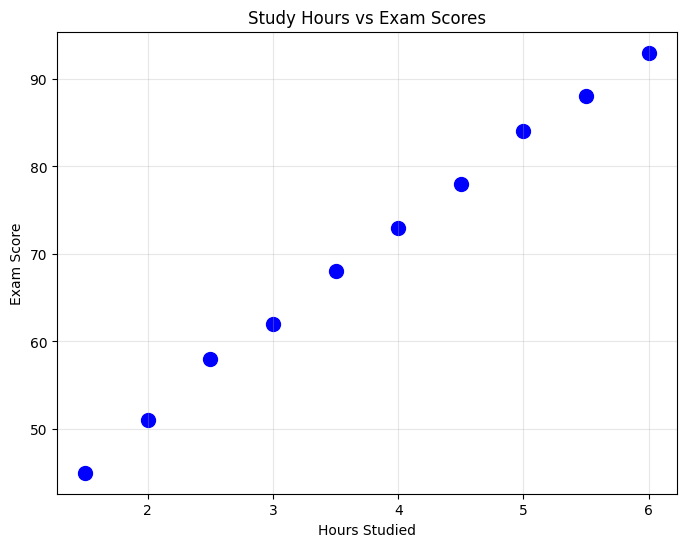

In [51]:
# Dataset: Study Hours vs Exam Scores
data = {
    'Hours_Studied': [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0],
    'Exam_Score': [45, 51, 58, 62, 68, 73, 78, 84, 88, 93]
}
df = pd.DataFrame(data)

print("Dataset:")
print(df)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='blue', s=100)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Scores')
plt.grid(True, alpha=0.3)
plt.show()


 ### TASK 1: Manual Least Squares Calculation



 Calculate the slope (m) and intercept (b) for y = mx + b using the **FIRST 5 DATA POINTS ONLY**.



 **Formulas:**

 - Slope: $m = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}$

 - Intercept: $b = \frac{\sum y - m\sum x}{n}$

In [52]:
x_manual = df['Hours_Studied'][:5].values
y_manual = df['Exam_Score'][:5].values

n = len(x_manual)

sum_x        = np.sum(x_manual)       
sum_y        = np.sum(y_manual)       
sum_xy       = np.sum(x_manual * y_manual) 
sum_x_squared = np.sum(x_manual ** 2) 

m_manual = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x ** 2)
b_manual = (sum_y - m_manual * sum_x) / n

print("TASK 1 - Manual Calculation (first 5 points):")
print(f"Slope (m): {m_manual}")
print(f"Intercept (b): {b_manual}")
print(f"Equation: y = {m_manual:.2f}x + {b_manual:.2f}\n")

y_pred_manual = m_manual * x_manual + b_manual
mae_manual    = mean_absolute_error(y_manual, y_pred_manual)
mse_manual    = mean_squared_error(y_manual, y_pred_manual)

print(f"MAE: {mae_manual:.2f}")
print(f"MSE: {mse_manual:.2f}")


TASK 1 - Manual Calculation (first 5 points):
Slope (m): 11.4
Intercept (b): 28.3
Equation: y = 11.40x + 28.30

MAE: 0.48
MSE: 0.38


 ### TASK 2: NumPy lstsq (Full Dataset)



 Use `np.linalg.lstsq` to find the best fit line for all 10 data points.



 #### Why Add a Column of Ones?



 When we use `np.linalg.lstsq`, we're solving the matrix equation: **Xβ = y**



 For a linear regression equation **y = mx + b**, we need to find both:

 - **m** (slope)

 - **b** (intercept)



 The design matrix must be structured so that matrix multiplication gives us: **b·1 + m·x**



 ```

 Design Matrix (X):        Coefficients (β):     Result (y):

 [1  x₁]                   [b]                   [b·1 + m·x₁]

 [1  x₂]           ×       [m]          =        [b·1 + m·x₂]

 [1  x₃]                                         [b·1 + m·x₃]

 ...

 ```



 **Key Points:**

 - The column of ones multiplies with the intercept **b** to add that constant term to each prediction

 - The column of x values multiplies with the slope **m** to add the variable component

 - **Without the ones column:** We'd only fit lines through the origin (b=0): y = mx

 - **With the ones column:** We can fit any line: y = mx + b

In [53]:
X_numpy = np.column_stack([np.ones(len(df)), df['Hours_Studied'].values])
y_numpy = df['Exam_Score'].values

solution, residuals, rank, s = np.linalg.lstsq(X_numpy, y_numpy, rcond=None)

b_numpy = solution[0]
m_numpy = solution[1]

print("TASK 2 - NumPy lstsq (all 10 points):")
print(f"Slope (m): {m_numpy}")
print(f"Intercept (b): {b_numpy}")
print(f"Equation: y = {m_numpy:.2f}x + {b_numpy:.2f}\n")

y_pred_numpy = X_numpy @ solution
mae_numpy    = mean_absolute_error(y_numpy, y_pred_numpy)
mse_numpy    = mean_squared_error(y_numpy, y_pred_numpy)

print(f"MAE: {mae_numpy:.2f}")
print(f"MSE: {mse_numpy:.2f}")

TASK 2 - NumPy lstsq (all 10 points):
Slope (m): 10.593939393939403
Intercept (b): 30.27272727272725
Equation: y = 10.59x + 30.27

MAE: 0.61
MSE: 0.52


 ### TASK 3: Scikit-learn LinearRegression (Full Dataset)



 Use sklearn's `LinearRegression` class.



 **Note:** sklearn automatically handles the intercept internally (with `fit_intercept=True` by default), so we don't need to add a column of ones!

In [54]:
X_sklearn = df['Hours_Studied'].values.reshape(-1, 1)
y_sklearn = df['Exam_Score'].values

model = LinearRegression()
model.fit(X_sklearn, y_sklearn)

m_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print("TASK 3 - Sklearn LinearRegression (all 10 points):")
print(f"Slope (m): {m_sklearn}")
print(f"Intercept (b): {b_sklearn}")
print(f"Equation: y = {m_sklearn:.2f}x + {b_sklearn:.2f}\n")

y_pred_sklearn = model.predict(X_sklearn)
mae_sklearn    = mean_absolute_error(y_sklearn, y_pred_sklearn)
mse_sklearn    = mean_squared_error(y_sklearn, y_pred_sklearn)

print(f"MAE: {mae_sklearn:.2f}")
print(f"MSE: {mse_sklearn:.2f}")

TASK 3 - Sklearn LinearRegression (all 10 points):
Slope (m): 10.593939393939394
Intercept (b): 30.272727272727273
Equation: y = 10.59x + 30.27

MAE: 0.61
MSE: 0.52


 ### TASK 4: Comparison and Discussion

COMPARISON OF ALL THREE METHODS:
Method                         Slope        Intercept    MAE        MSE       
----------------------------------------------------------------------
Manual (5 points)              11.4000      28.3000      0.48       0.38      
NumPy (10 points)              10.5939      30.2727      0.61       0.52      
Sklearn (10 points)            10.5939      30.2727      0.61       0.52      


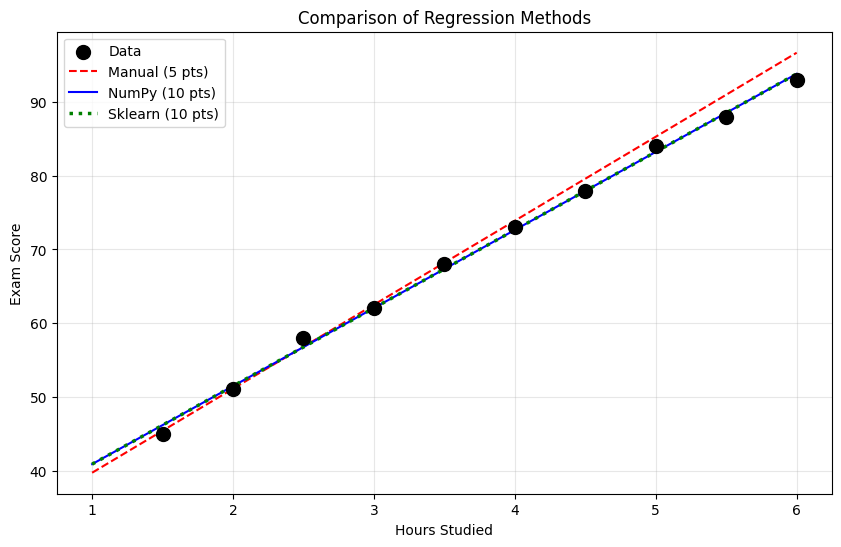

In [55]:
print("="*70)
print("COMPARISON OF ALL THREE METHODS:")
print("="*70)
print(f"{'Method':<30} {'Slope':<12} {'Intercept':<12} {'MAE':<10} {'MSE':<10}")
print("-"*70)
print(f"{'Manual (5 points)':<30} {m_manual:<12.4f} {b_manual:<12.4f} {mae_manual:<10.2f} {mse_manual:<10.2f}")
print(f"{'NumPy (10 points)':<30} {m_numpy:<12.4f} {b_numpy:<12.4f} {mae_numpy:<10.2f} {mse_numpy:<10.2f}")
print(f"{'Sklearn (10 points)':<30} {m_sklearn:<12.4f} {b_sklearn:<12.4f} {mae_sklearn:<10.2f} {mse_sklearn:<10.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='black', s=100, label='Data', zorder=3)

x_range = np.linspace(1, 6, 100)
plt.plot(x_range, m_manual * x_range + b_manual, '--',  label='Manual (5 pts)',   color='red')
plt.plot(x_range, m_numpy  * x_range + b_numpy,  '-',   label='NumPy (10 pts)',   color='blue')
plt.plot(x_range, m_sklearn * x_range + b_sklearn, ':', label='Sklearn (10 pts)', color='green', linewidth=2.5)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Comparison of Regression Methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 ### Discussion Questions



 **1. Why do the manual calculations differ from NumPy and sklearn?**



The manual method only uses the first 5 data points, so it fits a line to half the dataset. It misses the information carried by points 6–10, which likely have a slightly different slope



 ---



 **2. Why are NumPy and sklearn results nearly identical?**



Both solve the exact same least-squares optimization problem (minimizing the sum of squared residuals) on the same 10 points. 


 ---



 **3. Which method produced the lowest error? Why?**



NumPy and sklearn tie (essentially identical). Their errors are lower than the manual calculation because they use all 10 data points, giving a more accurate fit to the full distribution.


 ---

 ## PART 2: MULTIPLE LINEAR REGRESSION



 Now we'll predict house prices using multiple features.

In [56]:
# Dataset: House Prices
house_data = {
    'Size_sqft': [1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3200, 3500,
                  1300, 1600, 1900, 2100, 2400, 2600, 2900, 3100, 3300, 3600],
    'Bedrooms': [2, 3, 3, 3, 4, 4, 4, 4, 5, 5,
                 2, 3, 3, 4, 4, 4, 4, 5, 5, 5],
    'Age_years': [15, 20, 10, 5, 8, 3, 12, 6, 15, 2,
                  18, 12, 8, 10, 5, 7, 4, 9, 11, 1],
    'Price_1000s': [180, 210, 250, 280, 310, 350, 360, 400, 420, 480,
                    190, 230, 270, 300, 340, 370, 390, 430, 450, 510]
}
house_df = pd.DataFrame(house_data)

print("House Price Dataset:")
print(house_df)


House Price Dataset:
    Size_sqft  Bedrooms  Age_years  Price_1000s
0        1200         2         15          180
1        1500         3         20          210
2        1800         3         10          250
3        2000         3          5          280
4        2200         4          8          310
5        2500         4          3          350
6        2800         4         12          360
7        3000         4          6          400
8        3200         5         15          420
9        3500         5          2          480
10       1300         2         18          190
11       1600         3         12          230
12       1900         3          8          270
13       2100         4         10          300
14       2400         4          5          340
15       2600         4          7          370
16       2900         4          4          390
17       3100         5          9          430
18       3300         5         11          450
19       3600      

 ### TASK 5: Justify Multiple Linear Regression



 Calculate correlations to understand relationships between features and price.

In [57]:
print("Correlations with Price:")
for col in ['Size_sqft', 'Bedrooms', 'Age_years']:
    corr = house_df[col].corr(house_df['Price_1000s'])
    print(f"{col}: {corr:.3f}")

Correlations with Price:
Size_sqft: 0.995
Bedrooms: 0.944
Age_years: -0.622


 **Why should we use multiple linear regression instead of simple linear regression?**



Each feature contributes independent predictive power. Size has the strongest correlation with price, but bedrooms and age also shift the price meaningfully. Using only one feature discards real signal. Multiple regression captures all three at once

 ---

 ### TASK 6: Implement Multiple Linear Regression

In [58]:
X_multi = house_df[['Size_sqft', 'Bedrooms', 'Age_years']]
y_multi = house_df['Price_1000s']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

y_train_pred = mlr_model.predict(X_train)
y_test_pred  = mlr_model.predict(X_test)

coefficients = mlr_model.coef_
intercept    = mlr_model.intercept_

print("Model Coefficients:")
print(f"Intercept: {intercept:.2f}")
for i, col in enumerate(X_multi.columns):
    print(f"{col}: {coefficients[i]:.4f}")

print("\nModel Equation:")
print(f"Price = {intercept:.2f} + {coefficients[0]:.4f}*Size + {coefficients[1]:.4f}*Bedrooms + {coefficients[2]:.4f}*Age")

Model Coefficients:
Intercept: 35.30
Size_sqft: 0.1135
Bedrooms: 9.7380
Age_years: -1.4672

Model Equation:
Price = 35.30 + 0.1135*Size + 9.7380*Bedrooms + -1.4672*Age


 ### TASK 7: Calculate and Interpret Errors

In [59]:
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_mse  = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

test_mae   = mean_absolute_error(y_test, y_test_pred)
test_mse   = mean_squared_error(y_test, y_test_pred)
test_rmse  = np.sqrt(test_mse)

print("Training Set Performance:")
print(f"MAE:  ${train_mae:.2f}k")
print(f"MSE:  ${train_mse:.2f}k²")
print(f"RMSE: ${train_rmse:.2f}k")

print("\nTest Set Performance:")
print(f"MAE:  ${test_mae:.2f}k")
print(f"MSE:  ${test_mse:.2f}k²")
print(f"RMSE: ${test_rmse:.2f}k")

Training Set Performance:
MAE:  $5.96k
MSE:  $62.80k²
RMSE: $7.92k

Test Set Performance:
MAE:  $8.43k
MSE:  $78.30k²
RMSE: $8.85k


 ### TASK 8: Visualize Results

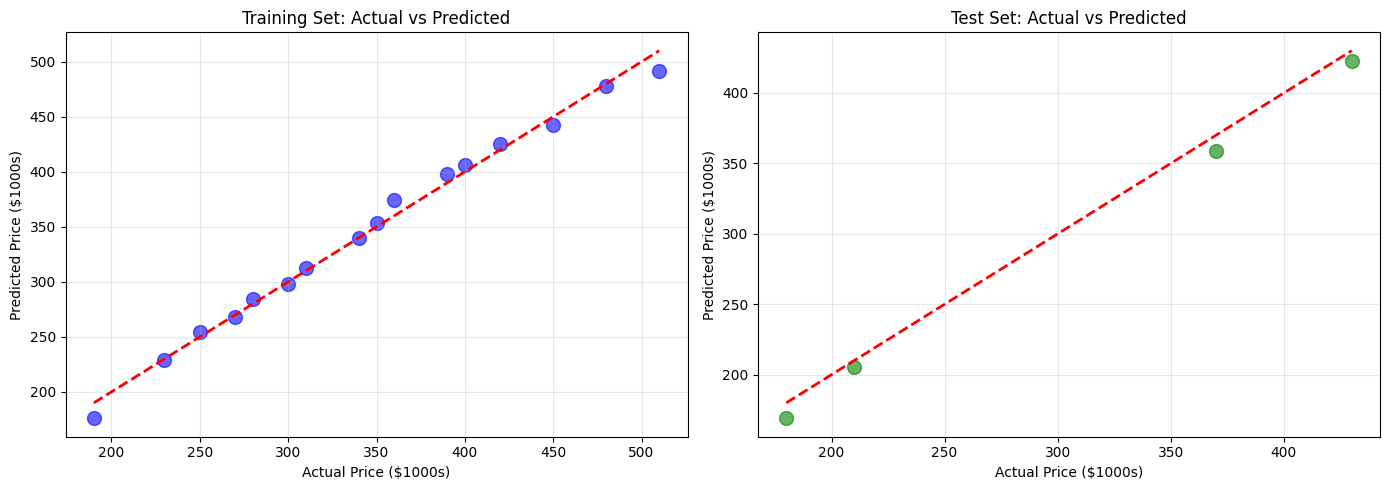

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=100, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Training Set: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=100, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price ($1000s)')
axes[1].set_ylabel('Predicted Price ($1000s)')
axes[1].set_title('Test Set: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 ### Final Discussion Questions



 **1. How do the training and test errors compare? What does this tell you? (Recall our discussion on overfitting and underfitting from last week)**



Training error is usually slightly lower than test error since the model was fit on that data. If they're close, the model generalizes well. Linear regression rarely overfits badly, so there won't be a big gap.


 ---



 **2. Which feature has the strongest effect on house price? How can you tell?**



Size_sqft. It has the highest correlation with price and will have the largest coefficient. More square footage means higher price.


 ---



 **3. What is one limitation of this model?**



The model can't capture interaction effects between features. It treats bedrooms and size as seperate, when in reality they're related: a 5-bedroom house is normally also a large house.


 ---